# 02 — Análise exploratória dos preços de medicamentos

**Pergunta principal:** quanto genéricos e similares custam em relação aos medicamentos novos
da mesma substância, e o que mais explica as diferenças de preço?

**Base:** saída do `01_limpeza.ipynb` (lista CMED de 09/09/2026).

**Preço usado:** PMC sem impostos (preço máximo ao consumidor sem a tributação de cada estado).
Lembrando que o PMC é um **teto regulatório**: o preço de prateleira pode ser menor.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
CORES_TIPO = {
    "Genérico": "#2a9d8f", "Similar": "#e9c46a", "Novo": "#e76f51",
    "Específico": "#8d99ae", "Biológico": "#6d597a", "Fitoterápico": "#90be6d",
}

PASTA_PROCESSED = Path("../data/processed")
PASTA_FIGURAS = Path("../reports/figures")
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

def salvar(fig, nome):
    fig.savefig(PASTA_FIGURAS / f"{nome}.png", dpi=150, bbox_inches="tight")

def formato_reais(eixo):
    eixo.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))

ARQUIVO = sorted(PASTA_PROCESSED.glob("cmed_limpo_*.csv"))[-1]
df_completo = pd.read_csv(ARQUIVO, parse_dates=["data_lista"])
print(ARQUIVO.name, df_completo.shape)

cmed_limpo_20260909.csv (26242, 29)


## 1. Recorte da análise

Para olhar o mercado de varejo de verdade, mantemos apenas apresentações que:
- foram **comercializadas** no ano anterior;
- **não** são de uso restrito hospitalar (essas não têm PMC);
- têm tipo de produto informado.

In [2]:
df = df_completo[
    df_completo["comercializado_ano_anterior"]
    & ~df_completo["restricao_hospitalar"]
    & df_completo["pmc_sem_impostos"].notna()
    & df_completo["tipo_produto"].notna()
].copy()

print(f"Base completa:   {len(df_completo):>6,} apresentações")
print(f"Base analisada:  {len(df):>6,} apresentações")
print(f"Substâncias:     {df['substancia'].nunique():>6,}")
print(f"Laboratórios:    {df['laboratorio'].nunique():>6,}")

Base completa:   26,242 apresentações
Base analisada:  10,983 apresentações
Substâncias:      1,532
Laboratórios:       190


## 2. Visão geral do mercado

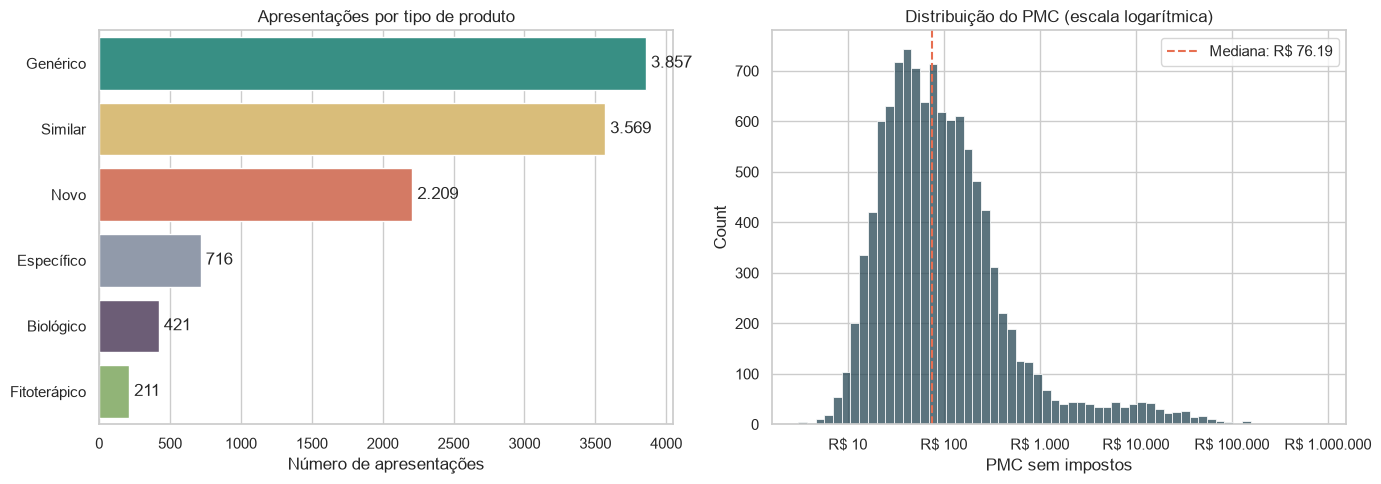

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contagem = df["tipo_produto"].value_counts()
sns.barplot(x=contagem.values, y=contagem.index, hue=contagem.index,
            palette=CORES_TIPO, legend=False, ax=axes[0])
axes[0].set_title("Apresentações por tipo de produto")
axes[0].set_xlabel("Número de apresentações")
axes[0].set_ylabel("")
for i, v in enumerate(contagem.values):
    axes[0].text(v, i, f" {v:,}".replace(",", "."), va="center")

sns.histplot(df["pmc_sem_impostos"], bins=60, log_scale=True, color="#264653", ax=axes[1])
axes[1].axvline(df["pmc_sem_impostos"].median(), color="#e76f51", ls="--",
                label=f"Mediana: R$ {df['pmc_sem_impostos'].median():,.2f}")
axes[1].set_title("Distribuição do PMC (escala logarítmica)")
axes[1].set_xlabel("PMC sem impostos")
axes[1].legend()
formato_reais(axes[1].xaxis)

plt.tight_layout()
salvar(fig, "01_visao_geral")
plt.show()

Os preços variam em várias ordens de grandeza (de poucos reais a centenas de milhares), por isso
usamos escala logarítmica. Genéricos e similares somam a maior parte das apresentações vendidas.

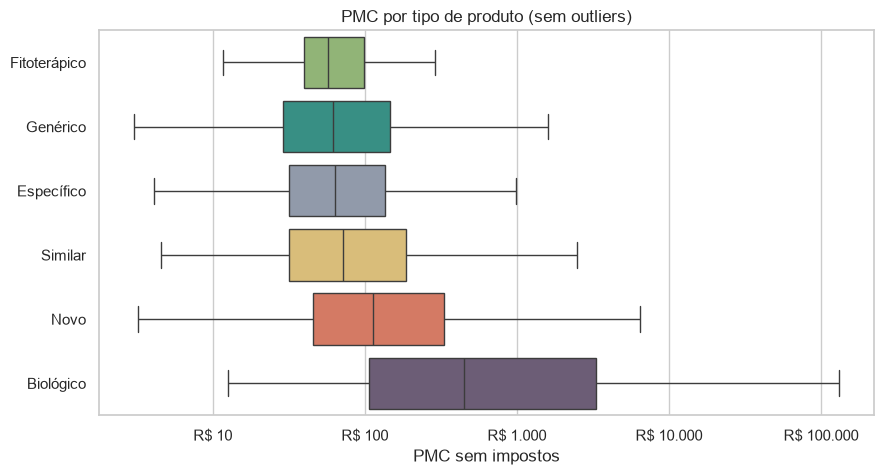

,count,25%,50%,75%
tipo_produto,,,,
Fitoterápico,211.00,39.75,57.04,99.41
Genérico,"3,857.00",28.92,61.34,145.20
Específico,716.00,31.85,63.80,135.14
Similar,"3,569.00",31.67,71.99,184.90
Novo,"2,209.00",45.81,113.76,333.51
Biológico,421.00,106.24,450.73,"3,314.06"


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ordem = df.groupby("tipo_produto")["pmc_sem_impostos"].median().sort_values().index
sns.boxplot(data=df, x="pmc_sem_impostos", y="tipo_produto", order=ordem,
            hue="tipo_produto", palette=CORES_TIPO, legend=False,
            log_scale=True, showfliers=False, ax=ax)
ax.set_title("PMC por tipo de produto (sem outliers)")
ax.set_xlabel("PMC sem impostos")
ax.set_ylabel("")
formato_reais(ax.xaxis)
salvar(fig, "02_pmc_por_tipo")
plt.show()

df.groupby("tipo_produto")["pmc_sem_impostos"].describe()[["count", "25%", "50%", "75%"]].sort_values("50%")

> **Cuidado com essa comparação.** Ela mistura substâncias, doses e tamanhos de embalagem diferentes.
> Biológicos são caros porque tratam doenças complexas, não por serem "biológicos".
> Para medir o efeito do tipo de produto, precisamos comparar **o mesmo medicamento**.

## 3. Comparação justa: mesmo medicamento, tipos diferentes

Criamos grupos de apresentações equivalentes combinando:
- **substância**;
- **dose + forma farmacêutica** (o texto da apresentação antes da embalagem, ex.: `50 MG COM REV`);
- **quantidade** da embalagem (ex.: `X 30`).

Diferenças de material da embalagem (blister transparente ou opaco, por exemplo) são ignoradas.

In [5]:
apres = (df["apresentacao"].str.upper()
         .str.replace(r"\s+", " ", regex=True)
         .str.strip())

# Dose + forma: tudo antes do primeiro termo de embalagem (CT = cartucho, FR = frasco, BL = blister...)
df["dose_forma"] = apres.str.extract(
    r"^(.*?)\s+(?:CT|FR|BL|ENV|CX|BG|CART|EST)\b", expand=False
).str.strip()

# Quantidade: número (e unidade, se houver) depois do "X"
df["quantidade"] = apres.str.extract(
    r"X\s*(\d+(?:,\d+)?\s*(?:ML|G|L|MG)?)", expand=False
).str.replace(" ", "")

print(f"Sem dose/forma identificada: {df['dose_forma'].isna().mean():.1%}")
print(f"Sem quantidade identificada: {df['quantidade'].isna().mean():.1%}")

df["grupo"] = df["substancia"] + " | " + df["dose_forma"] + " | " + df["quantidade"]
df[["substancia", "apresentacao", "dose_forma", "quantidade"]].sample(5, random_state=1)

Sem dose/forma identificada: 0.3%
Sem quantidade identificada: 1.0%


,substancia,apresentacao,dose_forma,quantidade
21158,PARACETAMOL,500 MG COM CT BL AL PLAS TRANS X 360,500 MG COM,360
10556,DESONIDA,"0,5 MG/G CREM DERM CT BG AL X 30G","0,5 MG/G CREM DERM",30G
21637,PREDNICARBATO,"2,5 MG/G CREM DERM CT BG AL X 20 G","2,5 MG/G CREM DERM",20G
19718,NITRATO DE CERIO;SULFADIAZINA DE PRATA,"1% + 0,4% CREM DERM CT BG PLAS OPC X 50 G","1% + 0,4% CREM DERM",50G
13879,FOSFATO DE CODEÍNA HEMI-HIDRATADO;DICLOFENACO ...,50 MG + 50 MG COM REV CT BL AL PLAS TRANS X 10,50 MG + 50 MG COM REV,10


In [6]:
com_grupo = df.dropna(subset=["grupo"])

# Mediana do PMC de cada tipo dentro de cada grupo
precos_grupo = (com_grupo
                .groupby(["grupo", "tipo_produto"])["pmc_sem_impostos"]
                .median()
                .unstack())

def comparar(tipo_a, tipo_b):
    pares = precos_grupo.dropna(subset=[tipo_a, tipo_b])
    razao = pares[tipo_a] / pares[tipo_b]
    return pd.Series({
        "grupos comparados": len(razao),
        "razão mediana": razao.median(),
        "diferença mediana": razao.median() - 1,
        "% de grupos em que o 1º é mais barato": (razao < 1).mean(),
    }, name=f"{tipo_a} vs {tipo_b}"), razao

resumo_gn, razao_gen_novo = comparar("Genérico", "Novo")
resumo_sn, razao_sim_novo = comparar("Similar", "Novo")
resumo_gs, razao_gen_sim = comparar("Genérico", "Similar")

resumo = pd.DataFrame([resumo_gn, resumo_sn, resumo_gs])
resumo.style.format({
    "grupos comparados": "{:,.0f}",
    "razão mediana": "{:.2f}",
    "diferença mediana": "{:+.0%}",
    "% de grupos em que o 1º é mais barato": "{:.0%}",
})

,grupos comparados,razão mediana,diferença mediana,% de grupos em que o 1º é mais barato
Genérico vs Novo,411,0.65,-35%,97%
Similar vs Novo,443,0.88,-12%,76%
Genérico vs Similar,857,0.81,-19%,72%


Para interpretar a tabela: a razão é `preço do primeiro tipo ÷ preço do segundo`.
Uma razão de 0,65 significa que o primeiro custa 35% menos.

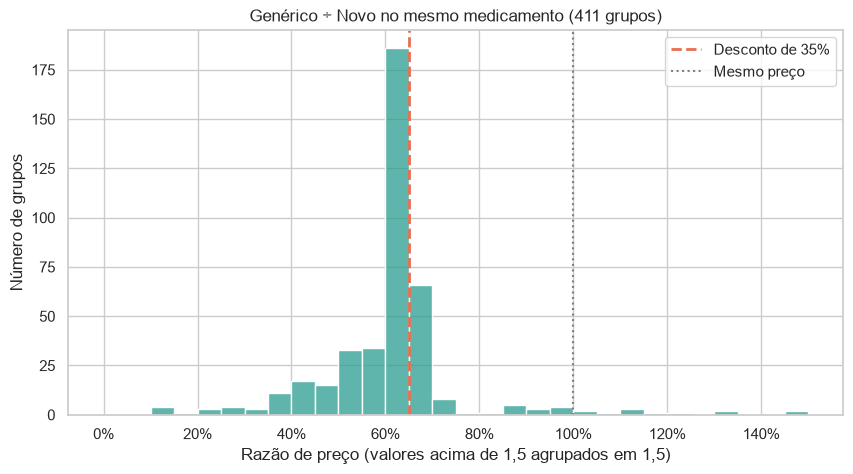

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(razao_gen_novo.clip(upper=1.5), bins=np.arange(0, 1.55, 0.05),
             color=CORES_TIPO["Genérico"], ax=ax)
ax.axvline(0.65, color="#e76f51", ls="--", lw=2, label="Desconto de 35%")
ax.axvline(1, color="gray", ls=":", label="Mesmo preço")
ax.set_title(f"Genérico ÷ Novo no mesmo medicamento ({len(razao_gen_novo)} grupos)")
ax.set_xlabel("Razão de preço (valores acima de 1,5 agrupados em 1,5)")
ax.set_ylabel("Número de grupos")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
salvar(fig, "03_generico_vs_novo")
plt.show()

**Principal achado:** a razão entre genérico e medicamento novo se concentra fortemente em torno de **65%**.
Isso reflete a regulação da CMED, que exige que o genérico entre no mercado com preço
pelo menos 35% menor que o do medicamento de referência. Na prática, grande parte dos genéricos
fica exatamente no teto permitido, em vez de competir com descontos maiores no PMC.

Os casos com razão acima de 1 merecem investigação: podem ser erros do agrupamento
(apresentações que não são realmente equivalentes) ou genéricos com preço regulado acima do produto novo.

In [8]:
casos = pd.DataFrame({
    "genérico": precos_grupo["Genérico"],
    "novo": precos_grupo["Novo"],
    "razão": razao_gen_novo,
}).dropna()

print("Genéricos proporcionalmente mais baratos:")
display(casos.nsmallest(5, "razão"))
print("Genéricos mais caros que o novo:")
display(casos[casos["razão"] > 1].sort_values("razão", ascending=False).head(8))

Genéricos proporcionalmente mais baratos:


,genérico,novo,razão
grupo,,,
CLORIDRATO DE CIPROFLOXACINO | 500 MG COM REV | 14,48.77,412.53,0.12
BESILATO DE ANLODIPINO | 10 MG COM | 60,41.66,307.17,0.14
ARIPIPRAZOL | 20 MG COM | 30,299.83,"2,064.58",0.15
CLORIDRATO DE FLUOXETINA | 20 MG CAP DURA | 30,50.86,340.26,0.15
ARIPIPRAZOL | 30 MG COM | 30,545.43,"3,096.84",0.18


Genéricos mais caros que o novo:


,genérico,novo,razão
grupo,,,
ÁCIDO TRANEXÂMICO | 50 MG/ML SOL INJ | 5ML,708.95,54.52,13.00
MONTELUCASTE DE SÓDIO | 4 MG COM MAST | 30,131.85,78.39,1.68
MONTELUCASTE DE SÓDIO | 5 MG COM MAST | 30,102.92,78.39,1.31
MONTELUCASTE DE SÓDIO | 10 MG COM REV | 30,102.82,78.39,1.31
MALEATO DE ENALAPRIL | 10 MG COM | 30,28.75,23.14,1.24
ATORVASTATINA CÁLCICA | 80 MG COM REV | 30,318.54,271.75,1.17
ACETILCISTEÍNA | 40 MG/ML XPE | 120ML,41.81,36.89,1.13
CLORIDRATO DE METFORMINA | 500 MG COM LIB PROL | 30,11.23,9.92,1.13


## 4. Concorrência e dispersão de preços

Com mais laboratórios vendendo o mesmo medicamento, a diferença entre o mais caro e o mais barato aumenta?
Medimos a dispersão como `maior PMC ÷ menor PMC` dentro de cada grupo.

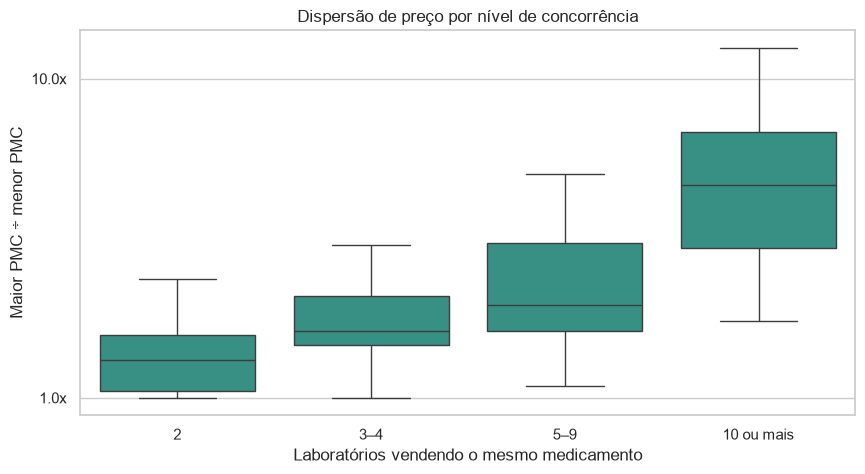

,count,50%,75%,max
faixa_concorrencia,,,,
2,534.00,1.32,1.57,50.05
3–4,393.00,1.62,2.09,114.03
5–9,235.00,1.95,3.04,61.90
10 ou mais,103.00,4.63,6.80,16.38


In [9]:
por_grupo = com_grupo.groupby("grupo").agg(
    laboratorios=("laboratorio", "nunique"),
    pmc_min=("pmc_sem_impostos", "min"),
    pmc_max=("pmc_sem_impostos", "max"),
    pmc_mediano=("pmc_sem_impostos", "median"),
)
por_grupo = por_grupo[por_grupo["laboratorios"] >= 2].copy()
por_grupo["dispersao"] = por_grupo["pmc_max"] / por_grupo["pmc_min"]
por_grupo["faixa_concorrencia"] = pd.cut(
    por_grupo["laboratorios"], bins=[1, 2, 4, 9, np.inf],
    labels=["2", "3–4", "5–9", "10 ou mais"],
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=por_grupo, x="faixa_concorrencia", y="dispersao",
            color="#2a9d8f", showfliers=False, ax=ax)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}x"))
ax.set_title("Dispersão de preço por nível de concorrência")
ax.set_xlabel("Laboratórios vendendo o mesmo medicamento")
ax.set_ylabel("Maior PMC ÷ menor PMC")
salvar(fig, "04_concorrencia_dispersao")
plt.show()

por_grupo.groupby("faixa_concorrencia", observed=True)["dispersao"].describe()[["count", "50%", "75%", "max"]]

Quanto mais laboratórios, maior a distância entre o preço máximo mais alto e o mais baixo
para o mesmo medicamento. Para o consumidor, isso significa que **pesquisar preço vale mais a pena
justamente nos medicamentos mais comuns**.

In [10]:
print("Maiores dispersões (com pelo menos 5 laboratórios):")
por_grupo[por_grupo["laboratorios"] >= 5].nlargest(10, "dispersao")

Maiores dispersões (com pelo menos 5 laboratórios):


,laboratorios,pmc_min,pmc_max,pmc_mediano,dispersao,faixa_concorrencia
grupo,,,,,,
DICLOFENACO POTÁSSICO | 50 MG COM REV | 20,5,9.71,601.07,24.54,61.90,5–9
CLOTRIMAZOL | 10 MG/G CREM DERM | 20G,8,11.41,702.56,15.53,61.57,5–9
ALBENDAZOL | 40 MG/ML SUS OR | 10ML,7,6.57,313.15,11.12,47.66,5–9
ACETATO DE DEXAMETASONA | 1 MG/G CREM DERM | 10G,8,11.86,194.95,12.15,16.44,5–9
BESILATO DE ANLODIPINO | 10 MG COM | 30,16,22.36,366.32,83.93,16.38,10 ou mais
CLORIDRATO DE CIPROFLOXACINO | 500 MG COM REV | 14,9,26.14,412.53,65.78,15.78,5–9
BESILATO DE ANLODIPINO | 5 MG COM | 30,16,12.78,195.00,49.18,15.26,10 ou mais
ATORVASTATINA CÁLCICA | 20 MG COM REV | 30,13,38.09,476.07,88.28,12.50,10 ou mais
SINVASTATINA | 20 MG COM REV | 30,11,15.58,182.48,46.82,11.71,10 ou mais


Alguns desses casos têm um preço máximo muito acima da mediana do grupo
(ex.: diclofenaco com mediana perto de R$ 25 e máximo acima de R$ 600).
Podem ser erros do agrupamento ou preços realmente atípicos. Separar uma coisa da outra
é exatamente o objetivo da etapa de **detecção de anomalias**.

## 5. Preços por área terapêutica

A primeira letra do código da classe terapêutica indica o grupo anatômico principal (classificação EphMRA/ATC).

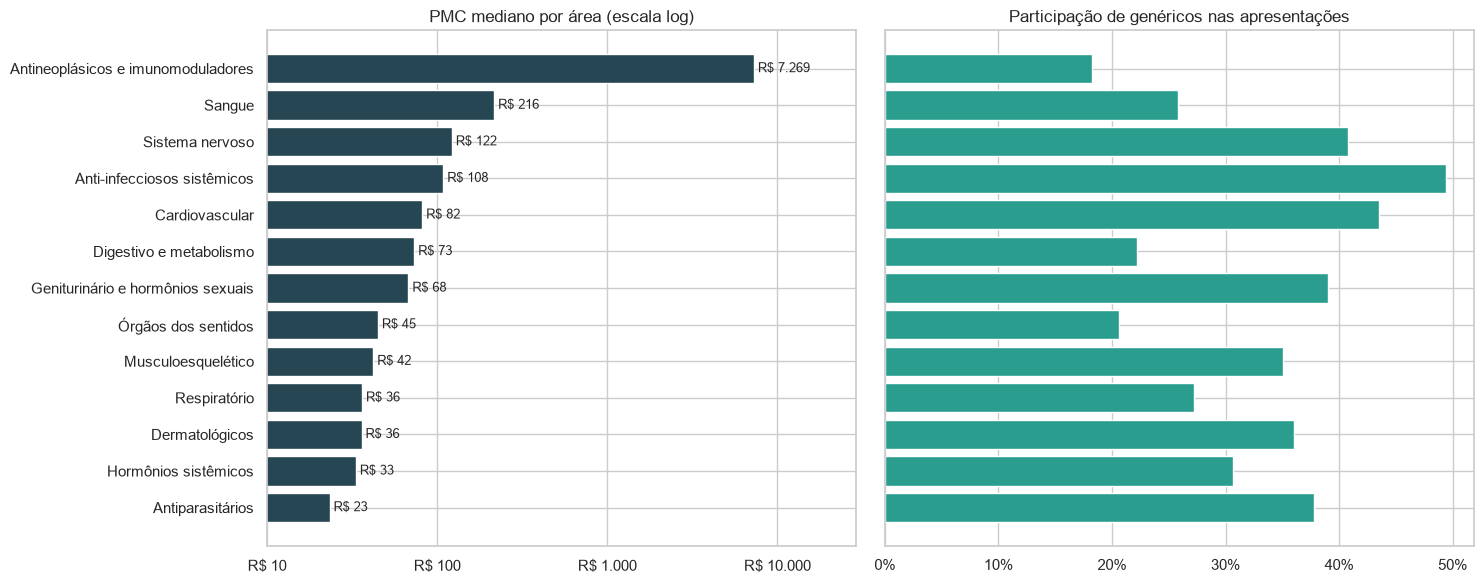

,apresentacoes,pmc_mediano,pct_genericos
area,,,
Antineoplásicos e imunomoduladores,384,"7,269.26",0.18
Sangue,422,215.89,0.26
Sistema nervoso,2509,121.78,0.41
Anti-infecciosos sistêmicos,852,108.46,0.49
Cardiovascular,1608,81.52,0.44
Digestivo e metabolismo,1463,73.20,0.22
Geniturinário e hormônios sexuais,745,67.64,0.39
Órgãos dos sentidos,267,44.79,0.21
Musculoesquelético,745,42.03,0.35


In [11]:
GRUPOS_ANATOMICOS = {
    "A": "Digestivo e metabolismo", "B": "Sangue", "C": "Cardiovascular",
    "D": "Dermatológicos", "G": "Geniturinário e hormônios sexuais",
    "H": "Hormônios sistêmicos", "J": "Anti-infecciosos sistêmicos",
    "K": "Soluções hospitalares", "L": "Antineoplásicos e imunomoduladores",
    "M": "Musculoesquelético", "N": "Sistema nervoso", "P": "Antiparasitários",
    "R": "Respiratório", "S": "Órgãos dos sentidos", "T": "Diagnóstico", "V": "Diversos",
}
df["area"] = df["grupo_anatomico"].map(GRUPOS_ANATOMICOS).fillna(df["grupo_anatomico"])

por_area = (df.groupby("area")
            .agg(apresentacoes=("pmc_sem_impostos", "size"),
                 pmc_mediano=("pmc_sem_impostos", "median"),
                 pct_genericos=("tipo_produto", lambda s: (s == "Genérico").mean()))
            .query("apresentacoes >= 30")
            .sort_values("pmc_mediano"))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
axes[0].barh(por_area.index, por_area["pmc_mediano"], color="#264653")
axes[0].set_xscale("log")
axes[0].set_xlim(10, por_area["pmc_mediano"].max() * 4)
axes[0].set_title("PMC mediano por área (escala log)")
for i, v in enumerate(por_area["pmc_mediano"]):
    axes[0].text(v, i, f" R$ {v:,.0f}".replace(",", "."), va="center", fontsize=9)
formato_reais(axes[0].xaxis)

axes[1].barh(por_area.index, por_area["pct_genericos"], color=CORES_TIPO["Genérico"])
axes[1].set_title("Participação de genéricos nas apresentações")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
salvar(fig, "05_areas_terapeuticas")
plt.show()

por_area.sort_values("pmc_mediano", ascending=False)

Oncologia e imunologia (grupo L) concentram os preços mais altos e têm pouca presença de genéricos,
em boa parte porque são medicamentos biológicos ou ainda protegidos por patente.

## 6. Os extremos

In [12]:
colunas_extremos = ["substancia", "produto", "laboratorio", "tipo_produto", "apresentacao", "pmc_sem_impostos"]
print("10 maiores PMCs da base analisada:")
df.nlargest(10, "pmc_sem_impostos")[colunas_extremos]

10 maiores PMCs da base analisada:


,substancia,produto,laboratorio,tipo_produto,apresentacao,pmc_sem_impostos
25860,VUTRISIRANA SÓDICA,AMVUTTRA,SPECIALTY PHARMA GOIAS LTDA,Novo,50 MG/ML SOL INJ SC CT SER PREENC VD TRANS X 0...,"829,924.38"
14481,GIVOSIRANA SÓDICA,GIVLAARI,SPECIALTY PHARMA GOIAS LTDA,Novo,189 MG/ML SOL INJ SC CT FA VD TRANS X 1ML,"350,264.64"
16358,INOTERSENA NONADECASSÓDICA,TEGSEDI,PTC FARMACEUTICA DO BRASIL LTDA.,Novo,200 MG/ML SOL INJ SC CT 4 ENVOL SER PREENC VD ...,"240,997.11"
1694,ATALURENO,TRANSLARNA,PTC FARMACEUTICA DO BRASIL LTDA.,Novo,1000 MG GRAN SUS OR CT 30 ENV AL,"211,420.97"
25828,VOLANESORSENA SÓDICA,WAYLIVRA,PTC FARMACEUTICA DO BRASIL LTDA.,Novo,200 MG/ML SOL INJ SC CT SER PREENC VD TRANS X ...,"176,173.21"
15008,HEMIFUMARATO DE GILTERITINIBE,XOSPATA®,ASTELLAS FARMA BRASIL IMPORTAÇÃO E DISTRIBUIÇÃ...,Novo,40 MG COM REV CT BL AL AL X 84,"144,901.82"
11966,ELEXACAFTOR;IVACAFTOR;TEZACAFTOR,TRIKAFTA,VERTEX FARMACEUTICA DO BRASIL LTDA.,Novo,"(50 + 25 + 37,5) MG COM REV + 75 MG COM REV CT...","137,817.88"
11967,ELEXACAFTOR;IVACAFTOR;TEZACAFTOR,TRIKAFTA,VERTEX FARMACEUTICA DO BRASIL LTDA.,Novo,(100 + 50 + 75) MG COM REV + 150 MG COM REV ...,"137,817.88"
24502,TAFAMIDIS MEGLUMINA,VYNDAQEL,PFIZER BRASIL LTDA,Novo,20 MG CAP MOLE CT BL AL PLAS TRANS X 120,"132,523.46"
24504,TAFAMIDIS MEGLUMINA,VYNDAQEL,PFIZER BRASIL LTDA,Novo,20 MG CAP MOLE CT BL AL AL X 120,"132,523.46"


In [13]:
print("Maior preço fábrica da lista completa (inclui uso hospitalar e não comercializados):")
df_completo.nlargest(3, "pf_sem_impostos")[
    ["substancia", "produto", "tipo_produto", "pf_sem_impostos",
     "restricao_hospitalar", "comercializado_ano_anterior"]
]

Maior preço fábrica da lista completa (inclui uso hospitalar e não comercializados):


,substancia,produto,tipo_produto,pf_sem_impostos,restricao_hospitalar,comercializado_ano_anterior
20338,ONASEMNOGENO ABEPARVOVEQUE,ZOLGENSMA,Produto de Terapia Avançada,"7,733,930.44",True,False
20339,ONASEMNOGENO ABEPARVOVEQUE,ZOLGENSMA,Produto de Terapia Avançada,"7,733,930.44",True,False
20340,ONASEMNOGENO ABEPARVOVEQUE,ZOLGENSMA,Produto de Terapia Avançada,"7,733,930.44",True,False


O maior preço da lista completa, na casa dos R$ 7,7 milhões, é o **onasemnogeno abeparvoveque**,
uma terapia gênica de dose única para atrofia muscular espinhal. Ele fica fora do recorte principal
porque é de uso restrito hospitalar e não aparece como comercializado no ano anterior segundo a própria lista.

No varejo, os preços mais altos são de medicamentos para **doenças raras** (terapias com RNA de interferência
e oligonucleotídeos antissenso), onde há um único fabricante e nenhuma concorrência.

## 7. Conclusões

1. **Genéricos custam, em mediana, cerca de 35% menos** que o medicamento novo equivalente,
   praticamente o desconto mínimo exigido pela regulação. O teto de preço do genérico
   parece funcionar mais como referência do que como ponto de partida para descontos maiores.
2. **Similares ficam no meio do caminho**: mais baratos que o novo, mas geralmente mais caros que o genérico.
3. **Mais concorrência significa mais dispersão de preço** no mesmo medicamento,
   o que torna a pesquisa de preço mais vantajosa justamente nos remédios mais comuns.
4. **Os preços mais altos estão em doenças raras e oncologia**, áreas com pouca ou nenhuma concorrência.

**Limitações:**
- O PMC é um teto; os preços efetivamente praticados podem ser menores.
- A lista não identifica o medicamento de referência, então usamos "Novo" como aproximação.
- O agrupamento por texto da apresentação não é perfeito e pode juntar itens não equivalentes
  (por isso usamos medianas, que são robustas a esses erros).

**Próximos passos:** clustering de medicamentos por perfil de preço e concorrência (`03_clustering.ipynb`)
e detecção de preços atípicos dentro de cada grupo.

In [14]:
# Salva a base com os grupos para os próximos notebooks
data_str = ARQUIVO.stem.split("_")[-1]
df.to_csv(PASTA_PROCESSED / f"cmed_analise_{data_str}.csv", index=False, encoding="utf-8")
por_grupo.to_csv(PASTA_PROCESSED / f"cmed_grupos_{data_str}.csv", encoding="utf-8")
print("Arquivos salvos em", PASTA_PROCESSED)

Arquivos salvos em ..\data\processed
